# Bass

This will play a bass guitar using a SuperCollider VST

In [161]:
from pythonosc.udp_client import SimpleUDPClient
from music21 import note, stream, tempo, bar, clef
import time

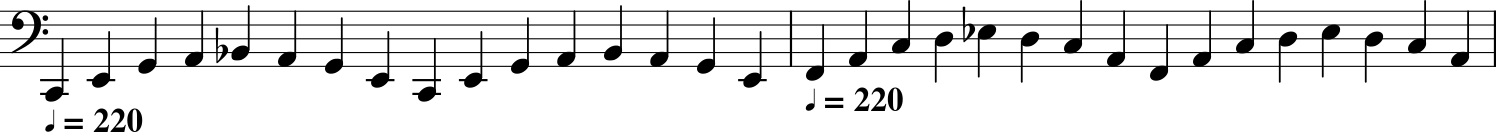

In [162]:
s = stream.Part()
t = stream.Stream()
t.append(clef.BassClef())
m1 = stream.Measure()
m1.append(tempo.MetronomeMark(number=220))
for i in range(0, 2):
    for name in ["C2", "E2", "G2", "A2", "B-2", "A2", "G2", "E2"]:
        n = note.Note(name)
        n.volume.velocity = 30 + i * 10
        m1.append(n)
t.append(m1)
m2 = m1.transpose("P4")
t.append(m2)
t.append(bar.Repeat(direction="End"))

# m.append(note.Note("G4"))
# m.append(note.Note("C4"))
s.append(t)

t.show()

In [170]:
client = SimpleUDPClient("192.168.1.151", 57121)
client.send_message("/vst/loopers", [0, 2])
time.sleep(1e-2)
for _ in range(2):
    for m in t:
        if isinstance(m, stream.Measure):
            for i in m:
                if isinstance(i, note.Note):
                    velocity = i.volume.velocity or 90
                    client.send_message(
                        "/bass", [i.pitch.midi, i.seconds, velocity]
                    )
                    print(i.pitch.midi, i.seconds, velocity)
                    time.sleep(i.seconds)

36 0.2727272727272727 30
40 0.2727272727272727 30
43 0.2727272727272727 30
45 0.2727272727272727 30
46 0.2727272727272727 30
45 0.2727272727272727 30
43 0.2727272727272727 30
40 0.2727272727272727 30
36 0.2727272727272727 40
40 0.2727272727272727 40
43 0.2727272727272727 40
45 0.2727272727272727 40


KeyboardInterrupt: 